In [1]:
import tensorflow as tf
print("Versi TensorFlow:", tf.__version__)
print("Jumlah GPU yang Tersedia:", len(tf.config.experimental.list_physical_devices('GPU')))

2024-03-20 10:11:46.953002: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-20 10:11:46.953117: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-20 10:11:47.115670: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Versi TensorFlow: 2.15.0
Jumlah GPU yang Tersedia: 1


In [2]:
import tensorflow as tf
print("GPU Tersedia:", tf.test.is_gpu_available())

GPU Tersedia: True


In [3]:
import pandas as pd

# Membaca file CSV
data = pd.read_csv('/kaggle/input/fix-round3-plain-cipher-label-all-new-shuffled/FIX-round3-plain-cipher-label-all-new-shuffled.csv', dtype={'plaintext': str, 'ciphertext': str})

# Menampilkan jumlah data dengan label 0 dan 1
label_counts = data['label'].value_counts()
print("Jumlah data dengan label 0:", label_counts[0])
print("Jumlah data dengan label 1:", label_counts[1])

Jumlah data dengan label 0: 524291
Jumlah data dengan label 1: 524288


In [4]:
data['label'].unique()

array([0, 1])

In [5]:
# Menampilkan tipe data dari tiap kolom
print("\nTipe data tiap kolom:")
print(data.dtypes)


Tipe data tiap kolom:
plaintext     object
ciphertext    object
label          int64
dtype: object


In [6]:
data.tail(3)

,plaintext,ciphertext,label
1048576,01001111010011010100011100100000,01110101101111100101100100011110,1
1048577,01101000011101000111010001110000,01110010011101011101010000101110,0
1048578,00100000011100110111010001110101,01101111000101010010111010001100,1


In [7]:
from sklearn.preprocessing import OneHotEncoder

import numpy as np
import tensorflow as tf
import pandas as pd
from sklearn.model_selection import train_test_split

# Mengkonversi data result menjadi representasi numerik (one-hot encoding)
data['concated_features'] = data['plaintext'] + data['ciphertext'].astype(str)

X = []
for binary_string in data['concated_features']:
    one_hot_encoding = [int(bit) for bit in binary_string]
    X.append(one_hot_encoding)

X = np.array(X, dtype=np.int64)
Y = data['label']

In [8]:
# Menampilkan tipe data dari tiap kolom
print("\nTipe data tiap kolom:")
print(data.dtypes)


Tipe data tiap kolom:
plaintext            object
ciphertext           object
label                 int64
concated_features    object
dtype: object


In [9]:
data.head(3)

,plaintext,ciphertext,label,concated_features
0,00100000011010100110010101101110,11111100110000000110001000011010,0,0010000001101010011001010110111011111100110000...
1,00100000011011010110100101100011,00001100110100101100011100011000,1,0010000001101101011010010110001100001100110100...
2,00100000011100110110000101101000,11011000100101010111000101000011,0,0010000001110011011000010110100011011000100101...


In [10]:
print(X)

[[0 0 1 ... 0 1 0]
 [0 0 1 ... 0 0 0]
 [0 0 1 ... 0 1 1]
 ...
 [0 1 0 ... 1 1 0]
 [0 1 1 ... 1 1 0]
 [0 0 1 ... 1 0 0]]


In [11]:
print(Y)

0          0
1          1
2          0
3          0
4          0
          ..
1048574    1
1048575    1
1048576    1
1048577    0
1048578    1
Name: label, Length: 1048579, dtype: int64


In [12]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from keras.layers import Input, Dense, Reshape
from keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Activation, Dense, LSTM
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, recall_score
import matplotlib.pyplot as plt

In [13]:
# Gunaka early-stopping untuk menentukan optimal epoch
my_callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10, restore_best_weights=True)
    #tf.keras.callbacks.LearningRateScheduler(scheduler, verbose=1)
]

In [14]:
input_shape = (64,1)  # Input shape for concated_features

In [15]:
lstm_model = Sequential()

# Layer LSTM pertama
lstm_model.add(LSTM(units=64, return_sequences=True, input_shape=input_shape))
lstm_model.add(LSTM(units=64, return_sequences=True))
lstm_model.add(LSTM(units=64, return_sequences=True))
lstm_model.add(LSTM(units=64, return_sequences=True))
lstm_model.add(LSTM(units=64, return_sequences=True))
lstm_model.add(LSTM(units=64))

# Output layer
lstm_model.add(Dense(1, activation='sigmoid'))

# Compile model
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print summary of the model
lstm_model.summary()

/opt/conda/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:205: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 182,081 (711.25 KB)

 Trainable params: 182,081 (711.25 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Training, validasi, dan tes
from sklearn.model_selection import train_test_split

# Memisahkan data menjadi training (60%), validasi (20%), dan test (20%)
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.2, random_state=42)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

# Output informasi ukuran dataset
print("Ukuran dataset pelatihan (X_train):", X_train.shape)
print("Ukuran dataset validasi (X_val):", X_val.shape)
print("Ukuran dataset pengujian (X_test):", X_test.shape)

Ukuran dataset pelatihan (X_train): (838863, 64)
Ukuran dataset validasi (X_val): (104858, 64)
Ukuran dataset pengujian (X_test): (104858, 64)


In [17]:
lstm_history = lstm_model.fit(X_train, Y_train, epochs=100, batch_size=100, callbacks=my_callbacks, validation_data=(X_val, Y_val))

Epoch 1/100
8389/8389 ━━━━━━━━━━━━━━━━━━━━ 228s 26ms/step - accuracy: 0.5145 - loss: 0.6906 - val_accuracy: 0.6459 - val_loss: 0.6104
Epoch 2/100
8389/8389 ━━━━━━━━━━━━━━━━━━━━ 224s 27ms/step - accuracy: 0.7206 - loss: 0.5261 - val_accuracy: 0.8284 - val_loss: 0.3722
Epoch 3/100
8389/8389 ━━━━━━━━━━━━━━━━━━━━ 224s 27ms/step - accuracy: 0.8416 - loss: 0.3479 - val_accuracy: 0.8539 - val_loss: 0.3311
Epoch 4/100
8389/8389 ━━━━━━━━━━━━━━━━━━━━ 224s 27ms/step - accuracy: 0.8780 - loss: 0.2823 - val_accuracy: 0.8880 - val_loss: 0.2637
Epoch 5/100
8389/8389 ━━━━━━━━━━━━━━━━━━━━ 225s 27ms/step - accuracy: 0.8964 - loss: 0.2470 - val_accuracy: 0.9004 - val_loss: 0.2410
Epoch 6/100
8389/8389 ━━━━━━━━━━━━━━━━━━━━ 225s 27ms/step - accuracy: 0.9093 - loss: 0.2198 - val_accuracy: 0.9060 - val_loss: 0.2281
Epoch 7/100
8389/8389 ━━━━━━━━━━━━━━━━━━━━ 225s 27ms/step - accuracy: 0.9179 - loss: 0.2020 - val_accuracy: 0.9076 - val_loss: 0.2258
Epoch 8/100
8389/8389 ━━━━━━━━━━━━━━━━━━━━ 225s 27ms/step - ac

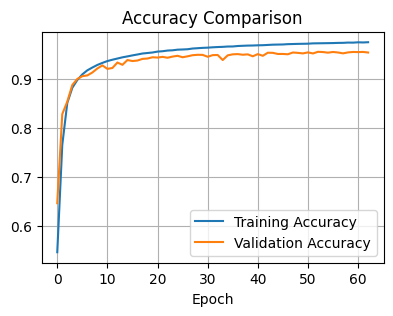

In [18]:
plt.figure(figsize=(15, 3))
plt.subplot(1, 3, 1)
plt.plot(lstm_history.history['accuracy'], label='Training Accuracy')
plt.plot(lstm_history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy Comparison')
plt.xlabel('Epoch')
plt.grid()

In [19]:
lstm_test_loss, lstm_test_accuracy = lstm_model.evaluate(X_test, Y_test)

3277/3277 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - accuracy: 0.9558 - loss: 0.1465


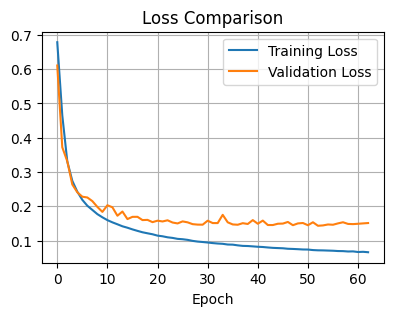

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 3))
plt.subplot(1, 3, 1)
plt.plot(lstm_history.history['loss'], label='Training Loss')
plt.plot(lstm_history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss Comparison')
plt.xlabel('Epoch')
plt.grid()
plt.show()

In [21]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import seaborn as sns

# Predict labels for test set
Y_pred = lstm_model.predict(X_test)
Y_pred_classes = np.round(Y_pred)

# Calculate confusion matrix
conf_matrix = confusion_matrix(Y_test, Y_pred_classes)

# Calculate evaluation metrics
accuracy = accuracy_score(Y_test, Y_pred_classes)
precision = precision_score(Y_test, Y_pred_classes)
recall = recall_score(Y_test, Y_pred_classes)

3277/3277 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step


In [22]:
print("Confusion Matrix:")
print(conf_matrix)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Confusion Matrix:
[[50228  2388]
 [ 2404 49838]]
Accuracy: 0.9543001010890919
Precision: 0.9542756481446023
Recall: 0.9539833850158876


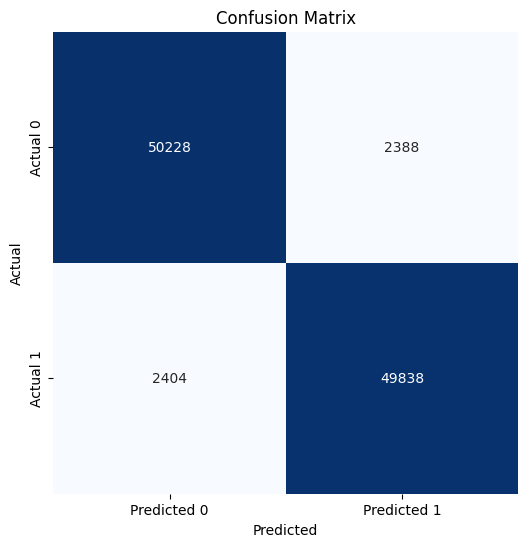

In [23]:
# Plot confusion matrix
plt.figure(figsize=(6, 6))
plt.title('Confusion Matrix')
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='g', cbar=False, 
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

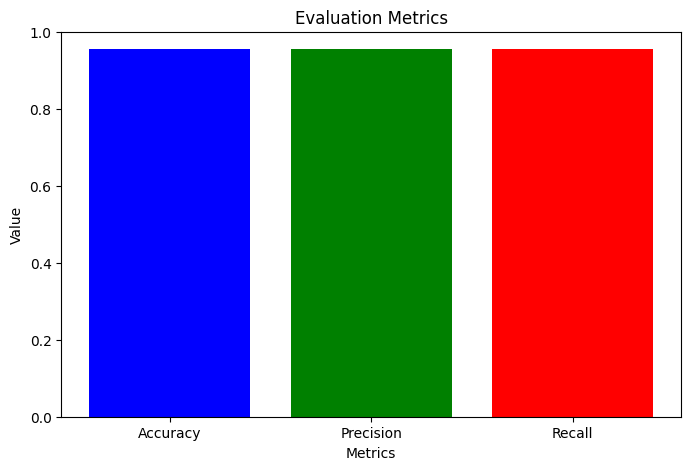

In [24]:
# Plot evaluation metrics
metrics = ['Accuracy', 'Precision', 'Recall']
values = [accuracy, precision, recall]

plt.figure(figsize=(8, 5))
plt.bar(metrics, values, color=['blue', 'green', 'red'])
plt.title('Evaluation Metrics')
plt.xlabel('Metrics')
plt.ylabel('Value')
plt.ylim(0, 1)
plt.show()